In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Datasets
vehicles = pd.read_csv(r"C:\Users\Tejaswi.k\OneDrive\Desktop\Municipal Fleet Optimization\data\vehicles.csv")
maintenance = pd.read_csv(r"C:\Users\Tejaswi.k\OneDrive\Desktop\Municipal Fleet Optimization\data\maintenance_records.csv")
fuel = pd.read_csv(r"C:\Users\Tejaswi.k\OneDrive\Desktop\Municipal Fleet Optimization\data\fuel_logs.csv")
inspections = pd.read_csv(r"C:\Users\Tejaswi.k\OneDrive\Desktop\Municipal Fleet Optimization\data\inspections.csv")
incidents = pd.read_csv(r"C:\Users\Tejaswi.k\OneDrive\Desktop\Municipal Fleet Optimization\data\incident_reports.csv")

In [3]:
# 3. Store Datasets
datasets = {
    "Vehicles": vehicles,
    "Maintenance": maintenance,
    "Fuel": fuel,
    "Inspections": inspections,
    "Incidents": incidents
}



In [4]:
# 4. Dataset Shape
for name, df in datasets.items():
    print(name, df.shape)

Vehicles (10000, 14)
Maintenance (14380, 18)
Fuel (10000, 9)
Inspections (10000, 13)
Incidents (10000, 9)


In [5]:
# 5. Basic Information
for name, df in datasets.items():
    print("\n", name)
    df.info()



 Vehicles
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   vehicle_id                10000 non-null  object 
 1   vehicle_type              10000 non-null  object 
 2   make                      10000 non-null  object 
 3   model_name                10000 non-null  object 
 4   model_year                10000 non-null  int64  
 5   department                10000 non-null  object 
 6   fuel_type                 10000 non-null  object 
 7   purchase_price_inr        10000 non-null  int64  
 8   odometer_km               10000 non-null  int64  
 9   vehicle_age_yrs           10000 non-null  int64  
 10  status_now                10000 non-null  object 
 11  status_future             10000 non-null  object 
 12  fleet_degradation_now     10000 non-null  float64
 13  fleet_degradation_future  10000 non-null  float64
d

In [6]:
# 6. First 5 Rows
display(vehicles.head())
display(maintenance.head())
display(fuel.head())
display(inspections.head())
display(incidents.head())


,vehicle_id,vehicle_type,make,model_name,model_year,department,fuel_type,purchase_price_inr,odometer_km,vehicle_age_yrs,status_now,status_future,fleet_degradation_now,fleet_degradation_future
0,VEH-00001,Fire Engine,Ashok Leyland,Dost Strong,2018,FIRE DEPARTMENT,Petrol,5557000,25256,6,Active,In Service,0.1848,0.2993
1,VEH-00002,Garbage Truck,Ashok Leyland,Captain 3520,2015,PUBLIC WORKS,Diesel,2384000,15116,9,Active,Active,0.1760,0.2389
2,VEH-00003,Motorcycle,Royal Enfield,Bullet 350,2013,POLICE DEPARTMENT,Diesel,3045000,88526,11,Active,Active,0.4420,0.4757
3,VEH-00004,SUV,Toyota,Innova Crysta,2016,POLICE DEPARTMENT,Diesel,2989000,98307,8,Active,Active,0.4875,0.5252
4,VEH-00005,Pipe Maintenance Van,Mahindra,Bolero Pik-Up,2022,WATER DEPARTMENT,Diesel,3767000,75461,2,Under Maintenance,Under Maintenance,0.4578,0.5569


,maintenance_id,vehicle_id,maintenance_date,maintenance_type,maintenance_code,cost_inr,downtime_days,description,now_maint_count,now_total_maint_cost,now_avg_parts_cost,now_avg_labor_cost,now_total_downtime_days,future_maint_count,future_total_maint_cost,future_avg_parts_cost,future_avg_labor_cost,future_total_downtime_days
0,MNT-000001,VEH-00001,2022-11-02,Corrective,CM-001,300.0,6.9,Radiator flush,3,900.0,165.0,135.0,11.4,4,1091.13,181.5,148.5,15.1
1,MNT-000002,VEH-00001,2022-09-18,Preventive,CM-002,300.0,3.3,Coolant flush and refill,3,900.0,165.0,135.0,11.4,4,1246.69,181.5,148.5,15.1
2,MNT-000003,VEH-00001,2024-10-27,Preventive,OVH-001,300.0,1.2,Fuel system cleaning,3,900.0,165.0,135.0,11.4,4,1187.64,181.5,148.5,15.1
3,MNT-000004,VEH-00002,2024-03-21,Corrective,PM-001,300.0,12.5,Radiator flush,1,300.0,165.0,135.0,12.5,1,383.88,181.5,148.5,19.2
4,MNT-000005,VEH-00004,2023-04-18,Inspection,OVH-002,300.0,6.3,Battery check and replacement,3,900.0,165.0,135.0,29.3,4,1032.13,181.5,148.5,42.6


,vehicle_id,now_avg_kmpl,now_avg_kmpl_inv,now_total_fuel_cost_inr,now_avg_co2_kg,future_avg_kmpl,future_avg_kmpl_inv,future_total_fuel_cost_inr,future_avg_co2_kg
0,VEH-00001,15.11,0.0662,149945.03,2.13,14.55,0.0687,162393.80,2.32
1,VEH-00002,18.88,0.0530,72200.54,2.39,18.26,0.0548,89812.14,2.86
2,VEH-00003,15.59,0.0641,510768.98,3.46,15.04,0.0665,569815.99,3.64
3,VEH-00004,14.65,0.0683,603902.61,3.61,13.21,0.0757,748453.99,4.08
4,VEH-00005,14.56,0.0687,466936.84,3.45,13.98,0.0715,568185.17,3.97


,vehicle_id,now_avg_inspection_score,now_inspection_gap_days,now_engine_score,now_brake_score,now_tire_score,now_fail_count,future_avg_inspection_score,future_inspection_gap_days,future_engine_score,future_brake_score,future_tire_score,future_fail_count
0,VEH-00001,89.7,114,91.1,92.6,89.5,2,83.6,148,88.0,91.6,86.6,4
1,VEH-00002,89.4,119,90.0,85.8,87.9,1,83.6,172,86.9,83.7,85.6,2
2,VEH-00003,77.1,175,78.8,73.9,69.4,2,76.1,212,73.6,69.0,66.7,4
3,VEH-00004,77.2,185,73.7,72.7,74.0,3,70.2,195,70.8,67.1,72.8,4
4,VEH-00005,71.7,159,77.6,68.1,79.9,2,69.9,181,72.0,64.3,77.3,3


,vehicle_id,now_incident_count,now_total_claim_amt_inr,now_total_downtime_inc_days,now_total_repair_cost_inr,future_incident_count,future_total_claim_amt_inr,future_total_downtime_inc_days,future_total_repair_cost_inr
0,VEH-00001,0,0.00,0.0,0.00,2,0.00,0.0,0.00
1,VEH-00002,0,0.00,0.0,0.00,1,0.00,0.0,0.00
2,VEH-00003,4,162981.50,10.7,62916.80,4,177627.22,12.4,82721.93
3,VEH-00004,0,0.00,0.0,0.00,0,0.00,0.0,0.00
4,VEH-00005,3,98270.14,8.1,90532.32,4,119988.40,10.9,107604.37


In [7]:
# 7. Missing Values
for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum())



 Vehicles
vehicle_id                  0
vehicle_type                0
make                        0
model_name                  0
model_year                  0
department                  0
fuel_type                   0
purchase_price_inr          0
odometer_km                 0
vehicle_age_yrs             0
status_now                  0
status_future               0
fleet_degradation_now       0
fleet_degradation_future    0
dtype: int64

 Maintenance
maintenance_id                0
vehicle_id                    0
maintenance_date              0
maintenance_type              0
maintenance_code              0
cost_inr                      0
downtime_days                 0
description                   0
now_maint_count               0
now_total_maint_cost          0
now_avg_parts_cost            0
now_avg_labor_cost            0
now_total_downtime_days       0
future_maint_count            0
future_total_maint_cost       0
future_avg_parts_cost         0
future_avg_labor_cost         

In [8]:
# 8. Duplicate Records
for name, df in datasets.items():
    print(name, "Duplicates:", df.duplicated().sum())



Vehicles Duplicates: 0
Maintenance Duplicates: 0
Fuel Duplicates: 0
Inspections Duplicates: 0
Incidents Duplicates: 0


In [9]:
# 9. Convert Date Columns
for df in datasets.values():
    for col in df.columns:
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")


In [10]:
# 10. Vehicle Status Analysis
if "vehicle_status" in vehicles.columns:
    print(vehicles["vehicle_status"].value_counts())
    vehicles["vehicle_status"].value_counts().plot(kind="bar")
    plt.title("Vehicle Status Distribution")
    plt.show()

vehicle_type
Water Tender            593
Pipe Maintenance Van    584
Inspection Van          565
Water Tanker            565
SUV                     561
Fire Engine             554
Rescue Van              553
Aerial Ladder Truck     548
Prison Van              543
Motorcycle              541
Sewer Cleaning Truck    525
Patrol Car              514
Tipper Truck            383
Road Roller             383
Garbage Truck           374
Dump Truck              368
Street Sweeper          331
Command Vehicle         202
Water Cannon            199
Paramedic Van           192
Mobile ICU              190
Ambulance               189
Armoured SUV            189
Rescue Tender           186
Defence Truck           168
Name: count, dtype: int64


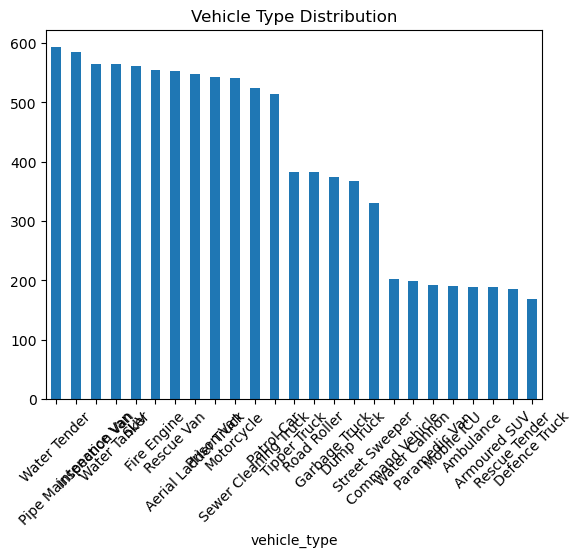

In [11]:
# 11. Vehicle Type Analysis
if "vehicle_type" in vehicles.columns:
    print(vehicles["vehicle_type"].value_counts())
    vehicles["vehicle_type"].value_counts().plot(kind="bar")
    plt.title("Vehicle Type Distribution")
    plt.xticks(rotation=45)
    plt.show()


department
FIRE DEPARTMENT      2248
WATER DEPARTMENT     2239
POLICE DEPARTMENT    2159
PUBLIC WORKS         1839
DEFENCE               758
EMR                   757
Name: count, dtype: int64


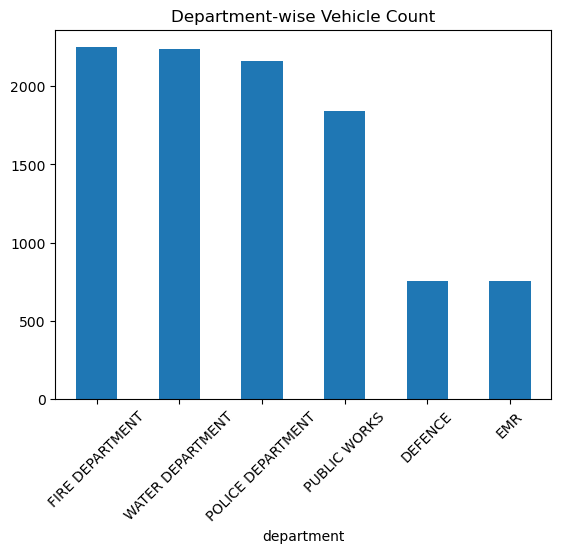

In [12]:
# 12. Department-wise Vehicle Count
if "department" in vehicles.columns:
    vehicles["department"] = vehicles["department"].astype(str).str.upper().str.strip()
    print(vehicles["department"].value_counts())
    vehicles["department"].value_counts().plot(kind="bar")
    plt.title("Department-wise Vehicle Count")
    plt.xticks(rotation=45)
    plt.show()



In [13]:
# 13. Maintenance Cost Summary
maintenance_cost_cols = [col for col in maintenance.columns if "cost" in col.lower()]
for col in maintenance_cost_cols:
    print(col)
    print(maintenance[col].describe())




cost_inr
count    14380.0
mean       300.0
std          0.0
min        300.0
25%        300.0
50%        300.0
75%        300.0
max        300.0
Name: cost_inr, dtype: float64
now_total_maint_cost
count    14380.000000
mean       608.970793
std        229.720690
min        300.000000
25%        300.000000
50%        600.000000
75%        900.000000
max        900.000000
Name: now_total_maint_cost, dtype: float64
now_avg_parts_cost
count    14380.0
mean       165.0
std          0.0
min        165.0
25%        165.0
50%        165.0
75%        165.0
max        165.0
Name: now_avg_parts_cost, dtype: float64
now_avg_labor_cost
count    14380.0
mean       135.0
std          0.0
min        135.0
25%        135.0
50%        135.0
75%        135.0
max        135.0
Name: now_avg_labor_cost, dtype: float64
future_total_maint_cost
count    14380.000000
mean       760.639803
std        292.499975
min        330.000000
25%        410.530000
50%        756.625000
75%       1040.002500
max       1259

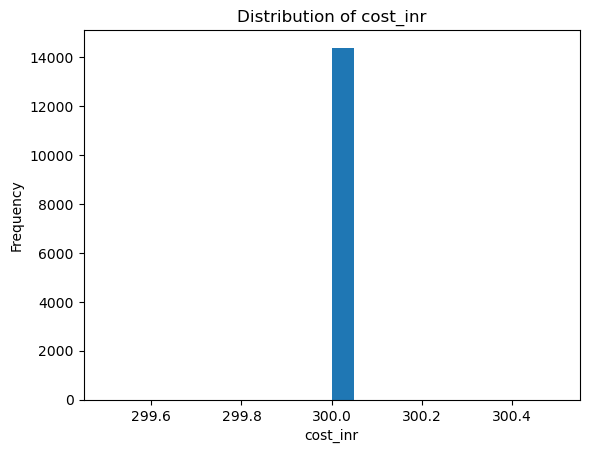

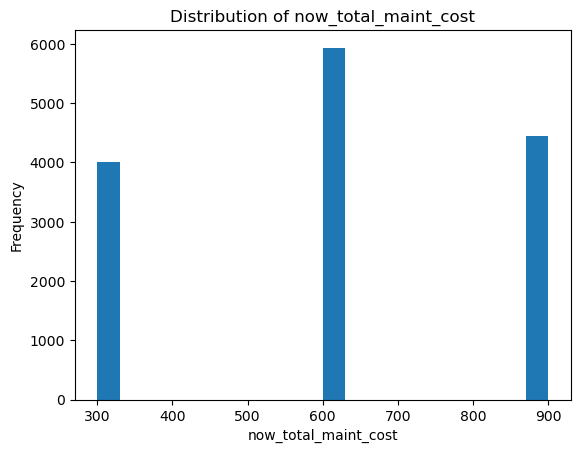

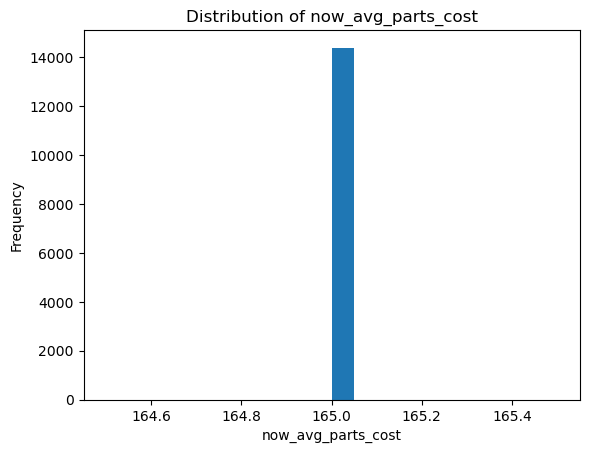

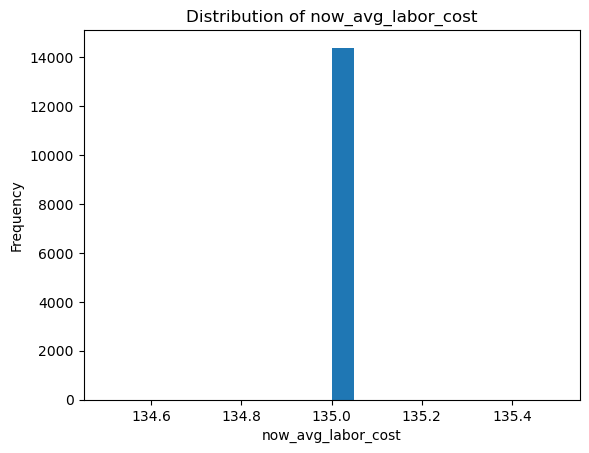

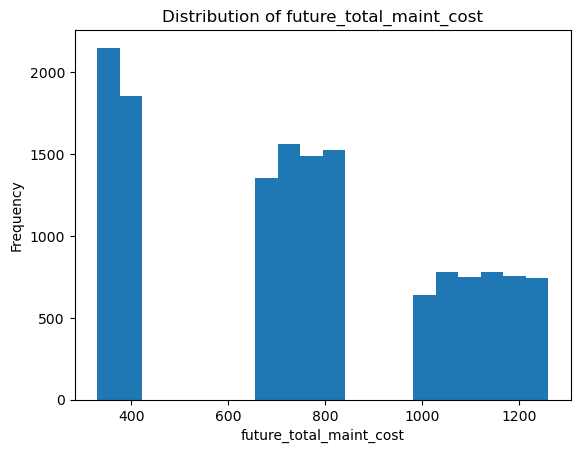

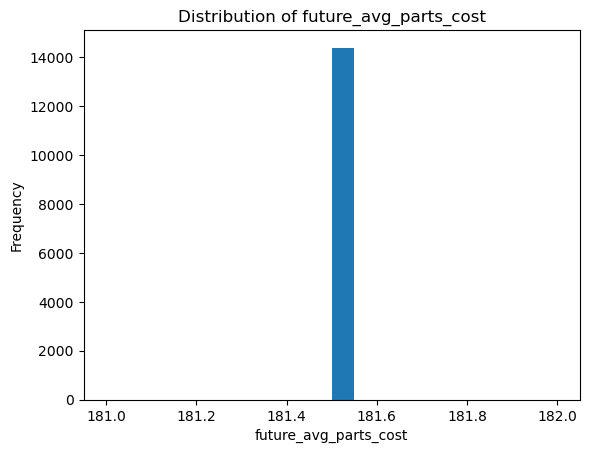

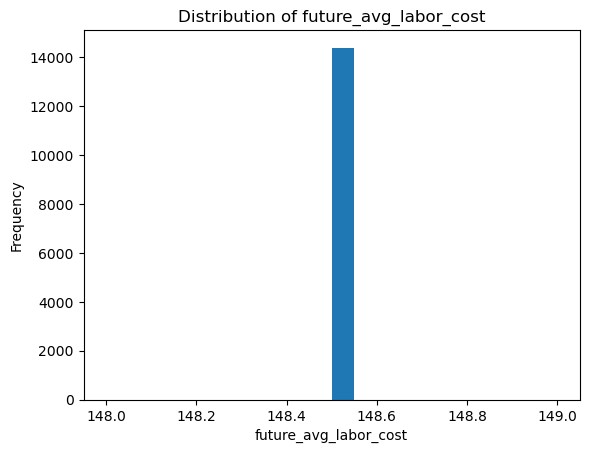

In [14]:
# 14. Maintenance Cost Distribution
for col in maintenance_cost_cols:
    maintenance[col].plot(kind="hist", bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()

maintenance_type
Corrective    300.0
Emergency     300.0
Inspection    300.0
Overhaul      300.0
Preventive    300.0
Name: cost_inr, dtype: float64


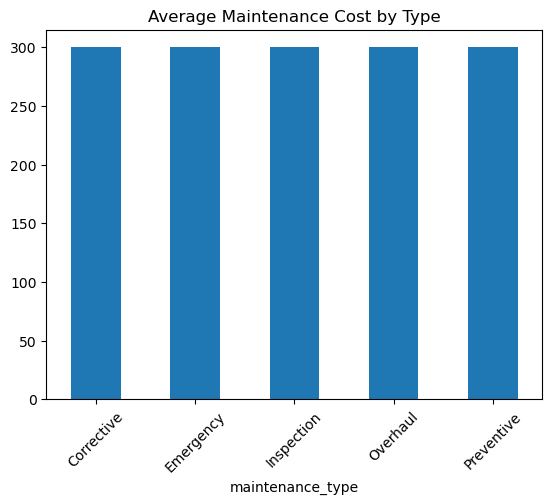

In [15]:
# 15. Maintenance Type Analysis
if "maintenance_type" in maintenance.columns and len(maintenance_cost_cols) > 0:
    cost_col = maintenance_cost_cols[0]
    result = maintenance.groupby("maintenance_type")[cost_col].mean().sort_values(ascending=False)
    print(result)
    result.plot(kind="bar")
    plt.title("Average Maintenance Cost by Type")
    plt.xticks(rotation=45)
    plt.show()

In [16]:
# 16. Component Repair Analysis
if "component_repaired" in maintenance.columns:
    print(maintenance["component_repaired"].value_counts())
    maintenance["component_repaired"].value_counts().plot(kind="bar")
    plt.title("Most Repaired Components")
    plt.xticks(rotation=45)
    plt.show()



In [17]:
# 17. Fuel Efficiency Summary
fuel_eff_cols = [
    col for col in fuel.columns
    if "kmpl" in col.lower() or "efficiency" in col.lower()
]

for col in fuel_eff_cols:
    print(col)
    print(fuel[col].describe())



now_avg_kmpl
count    10000.000000
mean        15.628880
std          2.173331
min          6.670000
25%         14.210000
50%         15.800000
75%         17.222500
max         20.000000
Name: now_avg_kmpl, dtype: float64
now_avg_kmpl_inv
count    10000.000000
mean         0.065378
std          0.010254
min          0.050000
25%          0.058075
50%          0.063300
75%          0.070400
max          0.149900
Name: now_avg_kmpl_inv, dtype: float64
future_avg_kmpl
count    10000.000000
mean        14.376912
std          2.211377
min          5.570000
25%         12.930000
50%         14.540000
75%         15.992500
max         19.490000
Name: future_avg_kmpl, dtype: float64
future_avg_kmpl_inv
count    10000.000000
mean         0.071445
std          0.012666
min          0.051300
25%          0.062500
50%          0.068800
75%          0.077300
max          0.179500
Name: future_avg_kmpl_inv, dtype: float64


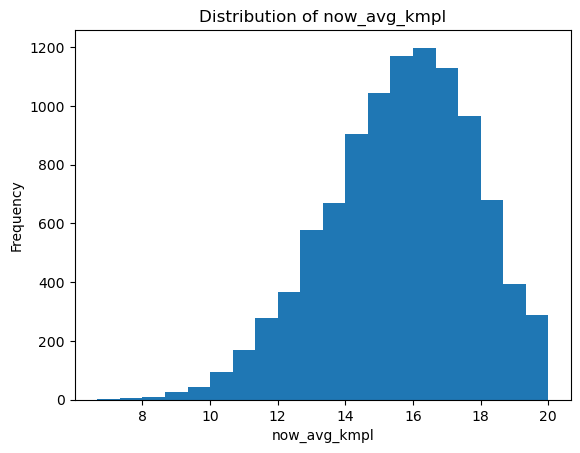

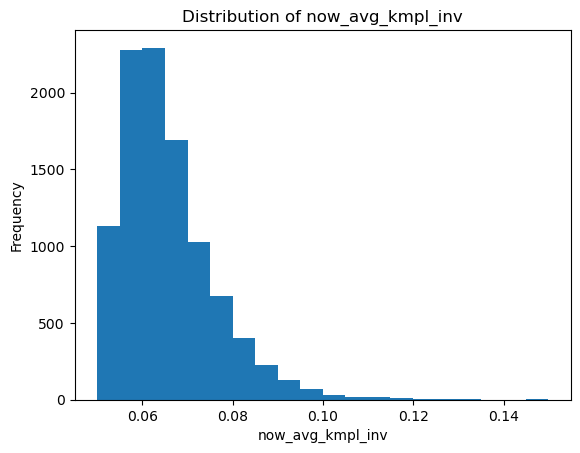

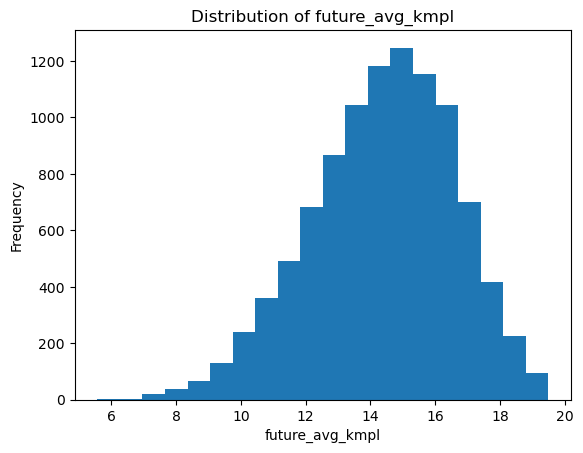

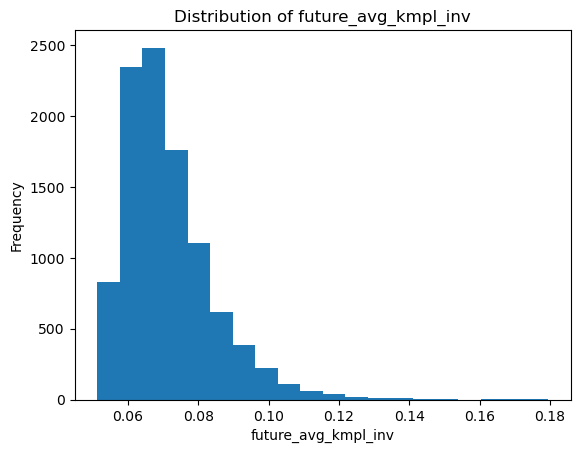

In [18]:
# 18. Fuel Efficiency Distribution
for col in fuel_eff_cols:
    fuel[col].plot(kind="hist", bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()



In [19]:
# 19. Fuel Type Analysis
if "fuel_type" in fuel.columns and len(fuel_eff_cols) > 0:
    eff_col = fuel_eff_cols[0]
    result = fuel.groupby("fuel_type")[eff_col].mean()
    print(result)
    result.plot(kind="bar")
    plt.title("Average Fuel Efficiency by Fuel Type")
    plt.show()



now_total_fuel_cost_inr
count    1.000000e+04
mean     4.100855e+05
std      2.540085e+05
min      2.146660e+04
25%      2.264154e+05
50%      3.555219e+05
75%      5.355085e+05
max      2.204986e+06
Name: now_total_fuel_cost_inr, dtype: float64


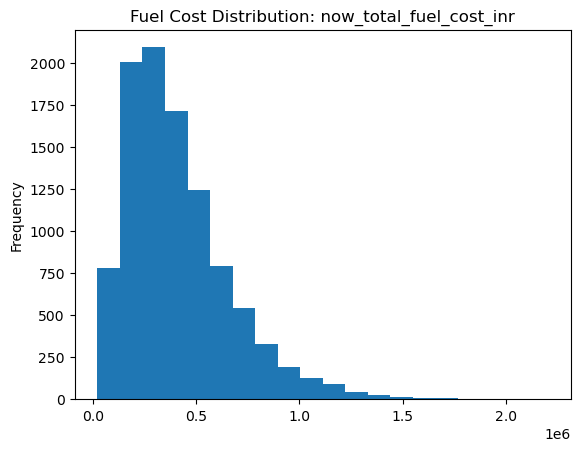

future_total_fuel_cost_inr
count    1.000000e+04
mean     4.780012e+05
std      2.967478e+05
min      2.480415e+04
25%      2.626578e+05
50%      4.153802e+05
75%      6.248963e+05
max      2.471813e+06
Name: future_total_fuel_cost_inr, dtype: float64


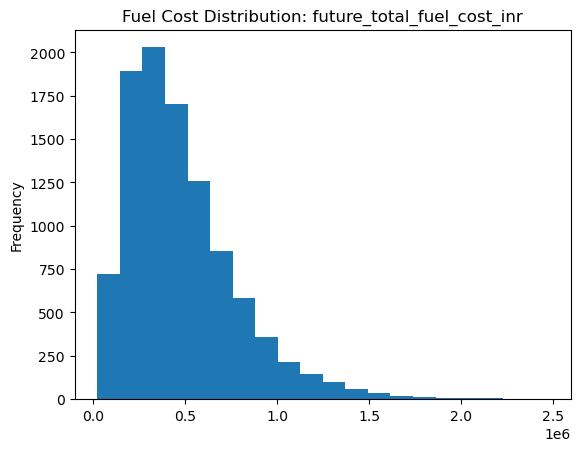

In [20]:
# 20. Fuel Cost Analysis
fuel_cost_cols = [col for col in fuel.columns if "cost" in col.lower()]
for col in fuel_cost_cols:
    print(col)
    print(fuel[col].describe())
    fuel[col].plot(kind="hist", bins=20)
    plt.title(f"Fuel Cost Distribution: {col}")
    plt.show()





In [21]:
# 21. Route Type Fuel Cost
if "route_type" in fuel.columns and len(fuel_cost_cols) > 0:
    cost_col = fuel_cost_cols[0]
    result = fuel.groupby("route_type")[cost_col].mean()
    print(result)
    result.plot(kind="bar")
    plt.title("Average Fuel Cost by Route Type")
    plt.xticks(rotation=45)
    plt.show()




In [22]:
# 22. Inspection Status Analysis
for col in inspections.columns:
    if "status" in col.lower() or "result" in col.lower():
        print(inspections[col].value_counts())
        inspections[col].value_counts().plot(kind="bar")
        plt.title(f"Inspection Analysis: {col}")
        plt.xticks(rotation=45)
        plt.show()


In [23]:
# 24. Incident Severity Analysis
for col in incidents.columns:
    if "severity" in col.lower():
        print(incidents[col].value_counts())
        incidents[col].value_counts().plot(kind="bar")
        plt.title("Incident Severity Distribution")
        plt.show()

In [24]:
# 25. Incident Type Analysis
for col in incidents.columns:
    if "type" in col.lower():
        print(incidents[col].value_counts())
        incidents[col].value_counts().plot(kind="bar")
        plt.title(f"Incident Type Analysis: {col}")
        plt.xticks(rotation=45)
        plt.show()

In [25]:
# 26. Merge Vehicles with Maintenance

vehicle_maintenance = maintenance.merge(
    vehicles,
    on="vehicle_id",
    how="left"
)

display(vehicle_maintenance.head())

,maintenance_id,vehicle_id,maintenance_date,maintenance_type,maintenance_code,cost_inr,downtime_days,description,now_maint_count,now_total_maint_cost,...,model_year,department,fuel_type,purchase_price_inr,odometer_km,vehicle_age_yrs,status_now,status_future,fleet_degradation_now,fleet_degradation_future
0,MNT-000001,VEH-00001,2022-11-02,Corrective,CM-001,300.0,6.9,Radiator flush,3,900.0,...,2018,FIRE DEPARTMENT,Petrol,5557000,25256,6,Active,In Service,0.1848,0.2993
1,MNT-000002,VEH-00001,2022-09-18,Preventive,CM-002,300.0,3.3,Coolant flush and refill,3,900.0,...,2018,FIRE DEPARTMENT,Petrol,5557000,25256,6,Active,In Service,0.1848,0.2993
2,MNT-000003,VEH-00001,2024-10-27,Preventive,OVH-001,300.0,1.2,Fuel system cleaning,3,900.0,...,2018,FIRE DEPARTMENT,Petrol,5557000,25256,6,Active,In Service,0.1848,0.2993
3,MNT-000004,VEH-00002,2024-03-21,Corrective,PM-001,300.0,12.5,Radiator flush,1,300.0,...,2015,PUBLIC WORKS,Diesel,2384000,15116,9,Active,Active,0.1760,0.2389
4,MNT-000005,VEH-00004,2023-04-18,Inspection,OVH-002,300.0,6.3,Battery check and replacement,3,900.0,...,2016,POLICE DEPARTMENT,Diesel,2989000,98307,8,Active,Active,0.4875,0.5252


vehicle_type
Armoured SUV            654.838710
Defence Truck           637.349398
Street Sweeper          628.163265
Water Cannon            626.384365
Water Tender            624.287343
Fire Engine             622.332506
Patrol Car              615.294118
Rescue Van              613.466334
Tipper Truck            611.602210
Rescue Tender           611.450382
Aerial Ladder Truck     610.012361
Paramedic Van           609.890110
Road Roller             609.677419
Water Tanker            609.225092
Prison Van              606.106870
Mobile ICU              603.272727
Inspection Van          602.992519
SUV                     600.733496
Dump Truck              598.259188
Sewer Cleaning Truck    596.774194
Command Vehicle         596.703297
Pipe Maintenance Van    594.074074
Garbage Truck           593.738140
Motorcycle              592.248062
Ambulance               590.476190
Name: now_total_maint_cost, dtype: float64


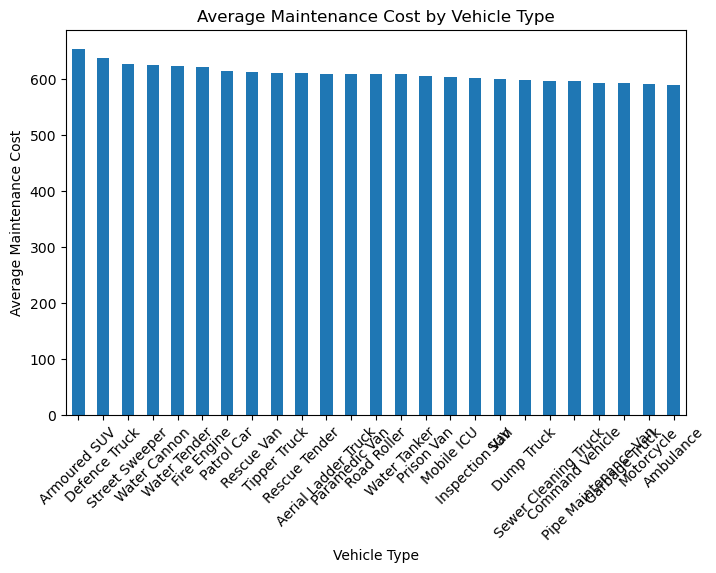

In [26]:
import matplotlib.pyplot as plt

# 27. Maintenance Cost by Vehicle Type

result = vehicle_maintenance.groupby(
    "vehicle_type"
)["now_total_maint_cost"].mean().sort_values(ascending=False)

print(result)

result.plot(kind="bar", figsize=(8,5), title="Average Maintenance Cost by Vehicle Type")

plt.title("Average Maintenance Cost by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Maintenance Cost")
plt.xticks(rotation=45)
plt.show()

In [27]:
# Use correct dataframe
df = fuel

# Find fuel efficiency column automatically
fuel_eff_cols = [
    col for col in df.columns
    if "mpg" in col.lower()
    or "kmpl" in col.lower()
    or "efficiency" in col.lower()
]

print("Detected efficiency columns:", fuel_eff_cols)



Detected efficiency columns: ['now_avg_kmpl', 'now_avg_kmpl_inv', 'future_avg_kmpl', 'future_avg_kmpl_inv']


In [28]:
# Use correct dataframe
df = fuel

# Find fuel efficiency column automatically
fuel_eff_cols = [
    col for col in df.columns
    if "mpg" in col.lower()
    or "kmpl" in col.lower()
    or "efficiency" in col.lower()
]

print("Detected efficiency columns:", fuel_eff_cols)


if "VehicleType" in df.columns and len(fuel_eff_cols) > 0:

    eff_col = fuel_eff_cols[0]

    # Convert safely
    df[eff_col] = pd.to_numeric(df[eff_col], errors="coerce")

    result = df.groupby("VehicleType")[eff_col].mean().sort_values()

    print(result)

    result.plot(kind="bar")
    plt.title("Average Fuel Efficiency by Vehicle Type")
    plt.xlabel("Vehicle Type")
    plt.ylabel("Average " + eff_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Detected efficiency columns: ['now_avg_kmpl', 'now_avg_kmpl_inv', 'future_avg_kmpl', 'future_avg_kmpl_inv']


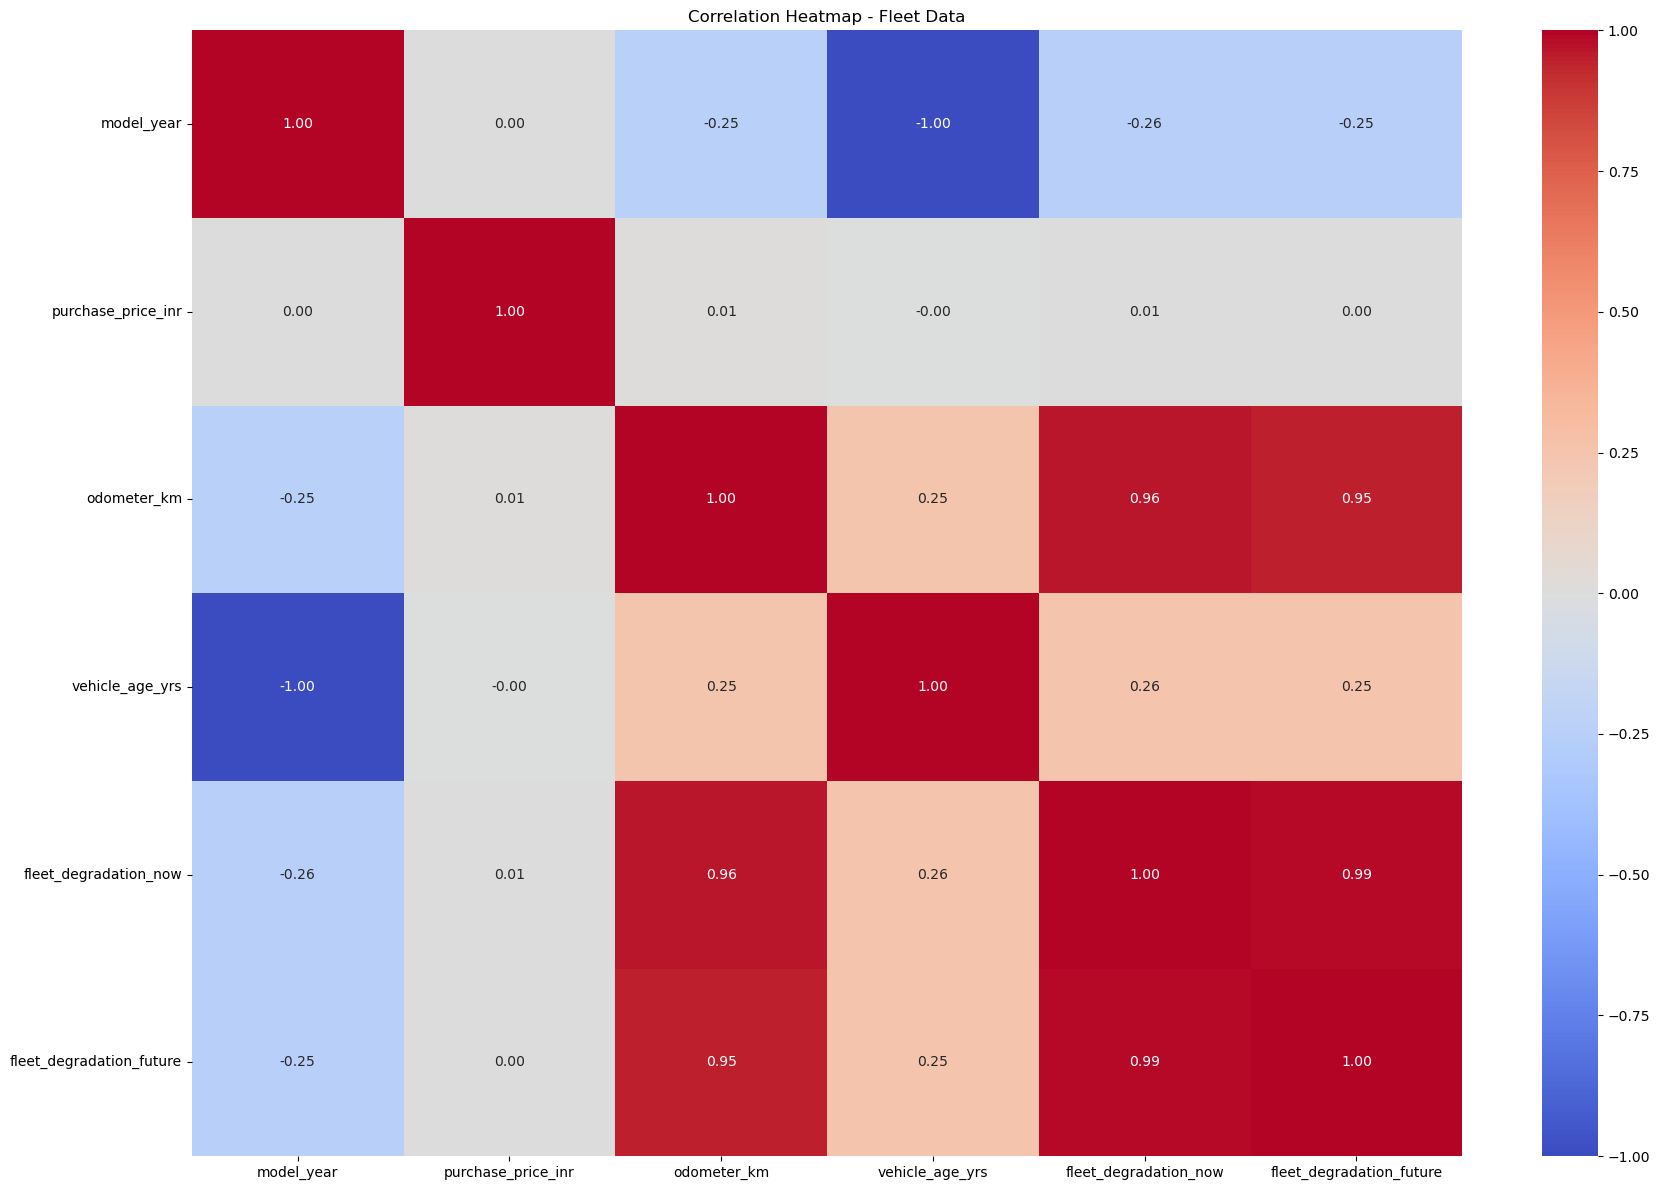

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

df = vehicles  # change to fuel if needed

numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(18, 12))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap - Fleet Data")
plt.tight_layout()
plt.show()

In [30]:
import numpy as np

corr = numeric_df.corr()

neg_count = (corr < 0).sum().sum()
total = corr.size

print("Negative values:", neg_count)
print("Total values:", total)
print("Negative %:", round(neg_count/total * 100, 2))

Negative values: 10
Total values: 36
Negative %: 27.78


In [31]:
vehicles.to_csv("cleaned_vehicles.csv", index=False)

maintenance.to_csv("cleaned_maintenance_records.csv", index=False)

fuel.to_csv("cleaned_fuel_logs.csv", index=False)

inspections.to_csv("cleaned_inspections.csv", index=False)

incidents.to_csv("cleaned_incident_reports.csv", index=False)

corr.to_csv("fleet_correlation_matrix.csv")

print("All cleaned files saved successfully!")

All cleaned files saved successfully!
